# Модуль 24. Как читать статью

Ноутбук к [модулю 24](https://drobyshevdev.github.io/lemma/modules/24-how-to-read-a-paper/).

Читать статью — значит проверять утверждение. Три вещи, которые проверка ловит чаще всего:

1. **Переживает ли прирост смену зерна.** Одинаковая заявка «+3% над базой» — и три разные судьбы.
2. **Настроенный метод против ненастроенной базы.** Как «прирост» появляется из неравного сравнения, без всякого метода.
3. **Отбор зерна.** Почему «лучший из десяти» систематически завышает результат.

Только `numpy` и `matplotlib`, всё детерминировано. **Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(24)

ACCENT = "#6f6af0"; GOLD = "#c99a3a"; GOOD = "#4a9d7f"; BAD = "#d0705f"; GREY = "#7a7a86"
plt.rcParams["figure.dpi"] = 110

SD = 1.4   # разброс точности между зёрнами, в процентных пунктах

## 1. Одна заявка, три судьбы

Три работы заявляют одно и то же: «+2.5% над базой». Но подкреплены по-разному.

- **Сильная:** эффект настоящий, база и метод прогнаны по 5 зёрен, показан интервал.
- **Слабая:** эффект настоящий, но прогон один — цифра пляшет от зерна к зерну.
- **Отозванная:** эффекта нет, но метод показан как **лучший из 10 зёрен** против среднего базы.

Проверим каждую тем, чего боится ложная заявка, — сменой зерна.

In [2]:
def acc(mu, n):
    return rng.normal(mu, SD, n)

BASE, GAIN = 76.0, 2.5     # истинная точность базы и истинный прирост сильного метода

# Сильная работа: 5 зёрен, честная база, оба метода реально различаются
def strong():
    m = acc(BASE + GAIN, 5); b = acc(BASE, 5)
    return m.mean() - b.mean()

# Слабая работа: тот же эффект, но одно зерно -- цифра шумная
def weak():
    return acc(BASE + GAIN, 1)[0] - acc(BASE, 1)[0]

# Отозванная: эффекта НЕТ, но берут лучший из 10 зёрен метода против среднего базы
def retracted():
    return acc(BASE, 10).max() - acc(BASE, 5).mean()

REP = 2000
d_strong = np.array([strong() for _ in range(REP)])
d_weak   = np.array([weak()   for _ in range(REP)])
d_retr   = np.array([retracted() for _ in range(REP)])

def ci(d):
    return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5)

# у каждой работы известен ИСТИННЫЙ прирост; сравниваем с ним заявленный
print("%-11s %8s %10s %-22s %s" % ("работа", "истинный", "заявлен", "95% интервал", "вердикт"))
for name, true, d in [("сильная", GAIN, d_strong), ("слабая", GAIN, d_weak), ("отозванная", 0.0, d_retr)]:
    m, lo, hi = ci(d)
    if lo <= 0 <= hi:
        verdict = "неотличимо от нуля — мало прогонов"
    elif abs(m - true) < 1.0:
        verdict = "прирост настоящий и переживает"
    else:
        verdict = "прирост выдуман — истинный эффект 0"
    print("%-11s %+7.1f %+9.1f   [%+.1f .. %+.1f]      %s" % (name, true, m, lo, hi, verdict))

работа      истинный    заявлен 95% интервал           вердикт
сильная        +2.5      +2.5   [+0.8 .. +4.3]      прирост настоящий и переживает
слабая         +2.5      +2.4   [-1.5 .. +6.5]      неотличимо от нуля — мало прогонов
отозванная     +0.0      +2.2   [+0.2 .. +4.4]      прирост выдуман — истинный эффект 0


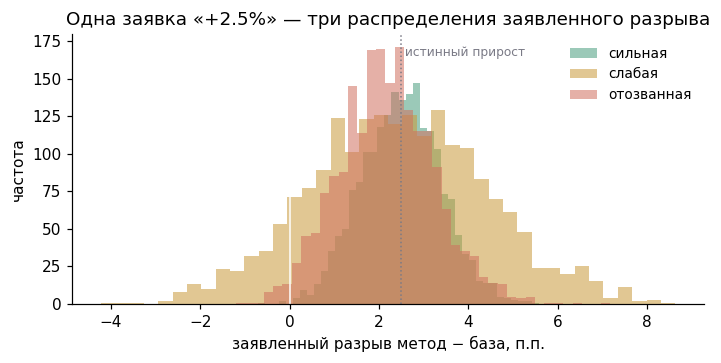

In [3]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
for d, c, lab in [(d_strong, GOOD, "сильная"), (d_weak, GOLD, "слабая"), (d_retr, BAD, "отозванная")]:
    ax.hist(d, bins=40, color=c, alpha=0.55, label=lab)
ax.axvline(0, color="white", lw=1)
ax.axvline(GAIN, color=GREY, ls=":", lw=1)
ax.text(GAIN, ax.get_ylim()[1] * 0.92, " истинный прирост", color=GREY, fontsize=8)
ax.set_xlabel("заявленный разрыв метод − база, п.п."); ax.set_ylabel("частота")
ax.set_title("Одна заявка «+2.5%» — три распределения заявленного разрыва")
ax.legend(frameon=False, fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Три работы, одна заявка «+2.5%» — и три разные истории под ней.

Сильная сидит на истинном приросте, её интервал не задевает ноль — прирост переживает смену зерна. Слабая — то же истинное среднее, но разброс огромный: одиночная цифра одинаково легко бывает и +6, и −1, отличить её от нуля нельзя. Отозванная центрирована на положительном разрыве, **хотя истинный эффект равен нулю**: весь «прирост» — отбор лучшего из десяти против среднего базы.

И тут важное: заявленную цифру у отозванной работы **нельзя разоблачить самой цифрой** — она стабильно положительна. Разоблачает её знание протокола («лучший из 10») или воспроизведение. Поэтому читают не число, а то, как оно получено.

## 2. Настроенный метод против ненастроенной базы

Частый источник ложного прироста — неравное сравнение. У метода и базы есть гиперпараметр; метод подобрали по сетке, а базу оставили на значении по умолчанию. «Прирост» появляется без всякого метода — из одной лишь неравной настройки.

In [4]:
thetas = np.linspace(0, 10, 41)
def perf(theta):                     # у метода и базы одна форма кривой качества
    return BASE + GAIN * 0.2 + 4.0 * np.exp(-0.5 * ((theta - 6.0) / 1.6) ** 2)

default_theta = 1.0                  # базу оставили на дефолте (далеко от оптимума)
untuned_base = perf(default_theta)
tuned_method = perf(thetas).max()    # метод подобрали по сетке
tuned_base   = perf(thetas).max()    # если так же настроить базу...

print("ненастроенная база : %.1f" % untuned_base)
print("метод (настроен)   : %.1f   -> заявленный прирост %+.1f" % (tuned_method, tuned_method - untuned_base))
print("база (настроена)   : %.1f   -> честный прирост     %+.1f" % (tuned_base, tuned_method - tuned_base))

ненастроенная база : 76.5
метод (настроен)   : 80.5   -> заявленный прирост +4.0
база (настроена)   : 80.5   -> честный прирост     +0.0


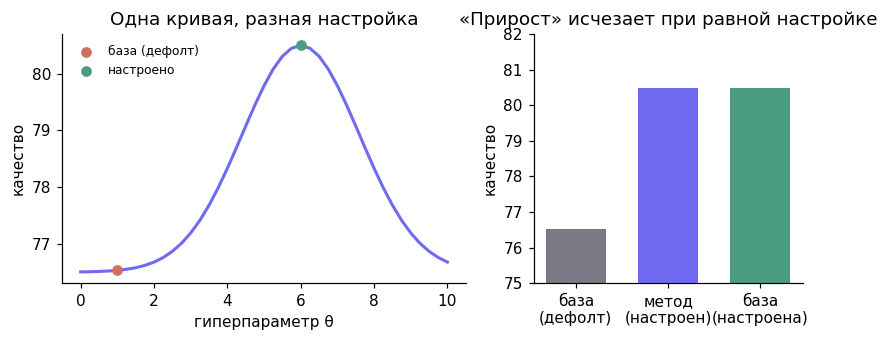

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(7.6, 3.2), gridspec_kw={"width_ratios": [3, 2]})
ax[0].plot(thetas, perf(thetas), color=ACCENT, lw=2)
ax[0].scatter([default_theta], [untuned_base], color=BAD, zorder=5, label="база (дефолт)")
ax[0].scatter([thetas[np.argmax(perf(thetas))]], [tuned_method], color=GOOD, zorder=5, label="настроено")
ax[0].set_xlabel("гиперпараметр θ"); ax[0].set_ylabel("качество")
ax[0].set_title("Одна кривая, разная настройка")
ax[0].legend(frameon=False, fontsize=8)
bars = ax[1].bar(["база\n(дефолт)", "метод\n(настроен)", "база\n(настроена)"],
                 [untuned_base, tuned_method, tuned_base], color=[GREY, ACCENT, GOOD], width=0.65)
ax[1].set_ylim(BASE - 1, tuned_method + 1.5); ax[1].set_ylabel("качество")
ax[1].set_title("«Прирост» исчезает при равной настройке")
for s in ("top", "right"):
    ax[0].spines[s].set_visible(False); ax[1].spines[s].set_visible(False)
plt.tight_layout(); plt.show()

Метод и база — одна и та же кривая качества. Весь заявленный прирост — это разница между настроенным методом и базой на дефолте. Настройте базу так же тщательно — и разрыв схлопывается. Метода тут нет вообще: есть неравное сравнение. Это [модуль 7](https://drobyshevdev.github.io/lemma/modules/07-honest-comparison/): базу настраивают так же честно, как метод, иначе сравнение ничего не значит.

## 3. Отбор зерна

«Мы достигли 79.8%» — а следующей строкой стоит «(лучший из 10 запусков)». Из десяти прогонов шумного метода всегда найдётся один красивый. Честное число — среднее (`pass@1`, [модуль 23](https://drobyshevdev.github.io/lemma/modules/23-evaluating-agents/)), а не максимум.

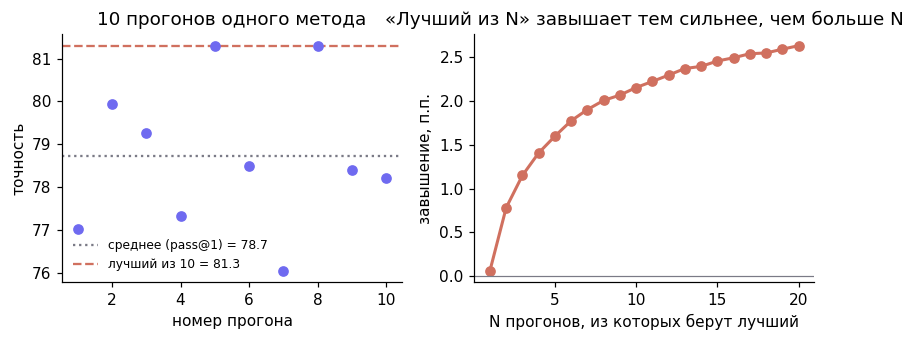

pass@1 = 78.7, лучший из 10 = 81.3  (завышение +2.6 п.п. без всякого улучшения метода)


In [6]:
runs = acc(BASE + GAIN, 10)        # 10 честных прогонов одного метода
pass1 = runs.mean()                 # честное ожидание одного прогона
best  = runs.max()                  # то, что часто печатают

# насколько систематически завышает "лучший из N"
Ns = np.arange(1, 21)
best_bias = np.array([np.mean([acc(BASE + GAIN, n).max() for _ in range(1500)]) for n in Ns]) - (BASE + GAIN)

fig, ax = plt.subplots(1, 2, figsize=(7.6, 3.2))
ax[0].scatter(np.arange(1, 11), runs, color=ACCENT, zorder=5)
ax[0].axhline(pass1, color=GREY, ls=":", label="среднее (pass@1) = %.1f" % pass1)
ax[0].axhline(best, color=BAD, ls="--", label="лучший из 10 = %.1f" % best)
ax[0].set_xlabel("номер прогона"); ax[0].set_ylabel("точность"); ax[0].set_title("10 прогонов одного метода")
ax[0].legend(frameon=False, fontsize=8)
ax[1].plot(Ns, best_bias, "o-", color=BAD, lw=2)
ax[1].axhline(0, color=GREY, lw=0.8)
ax[1].set_xlabel("N прогонов, из которых берут лучший"); ax[1].set_ylabel("завышение, п.п.")
ax[1].set_title("«Лучший из N» завышает тем сильнее, чем больше N")
for s in ("top", "right"):
    ax[0].spines[s].set_visible(False); ax[1].spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("pass@1 = %.1f, лучший из 10 = %.1f  (завышение %+.1f п.п. без всякого улучшения метода)" % (
    pass1, best, best - pass1))

«Лучший из 10» стоит выше среднего на величину, которая растёт с числом прогонов, — и всё это без единого изменения в методе. Читая статью, всегда ищите приписку «лучший из N» и мысленно возвращайте число к среднему.

## Что дальше

- Постройте таблицу с перекрывающимися интервалами метода и базы и покажите, что заявленный разрыв неотличим от шума.
- Смоделируйте утечку теста: обучите «на всех данных», включая тест, и покажите, насколько раздувается отчётная точность.
- В [модуле 25](https://drobyshevdev.github.io/lemma/programme/) — как устроена область, из которой берутся эти статьи, и почему лидерборд усиливает ровно эти три ловушки.